# Tracer Gradients

This notebook is to calculate tracer gradients in 3 spatial dimensions. I think this will help with interpretation of the results metrics.

## Housekeeping

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
import matplotlib.colors as colors
import pandas as pd
import numpy as np
from importlib import reload
import cartopy.crs as ccrs
import cmocean.cm as cmo
import gsw
import scipy.ndimage as filter
import scipy.interpolate as interpolate
from flox.xarray import xarray_reduce
from xgcm.autogenerate import generate_grid_ds
from xgcm import Grid
from tqdm.notebook import tqdm
from scipy.ndimage import uniform_filter1d

In [2]:
import os
os.chdir('/home/amf2288/argo-intern/funcs')
import filt_funcs as ff
import density_funcs as df

In [3]:
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize']  = 18
plt.rcParams['axes.labelsize']  = 14
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14

In [4]:
ds_r_grid = xr.open_dataset('/swot/SUM05/amf2288/ds_r_grid_copilot.nc')

In [5]:
ds_r_grid = ds_r_grid.rename_vars({'CT_sort':'CT_m_bin', 'SA_sort':'SA_m_bin', 'SPICE_sort':'SPICE_m_bin',
                                   'PRESSURE':'PRESSURE_m_bin'})

In [6]:
ds_r_grid

<xarray.Dataset> Size: 2GB
Dimensions:         (DENSITY: 6000, LON: 120, LAT: 60, LON_left: 120,
                     LAT_left: 60)
Coordinates:
  * DENSITY         (DENSITY) float64 48kB 22.0 22.0 22.0 ... 28.0 28.0 28.0
  * LON             (LON) float64 960B -178.5 -175.5 -172.5 ... 175.5 178.5
  * LAT             (LAT) float64 480B -88.5 -85.5 -82.5 ... 82.5 85.5 88.5
  * LON_left        (LON_left) float64 960B -180.0 -177.0 -174.0 ... 174.0 177.0
  * LAT_left        (LAT_left) float64 480B -90.0 -87.0 -84.0 ... 81.0 84.0 87.0
Data variables:
    CT_m_bin        (DENSITY, LON, LAT) float64 346MB ...
    SA_m_bin        (DENSITY, LON, LAT) float64 346MB ...
    SPICE_m_bin     (DENSITY, LON, LAT) float64 346MB ...
    PRESSURE_m_bin  (DENSITY, LON, LAT) float64 346MB ...
    PRESSURE_sort   (DENSITY, LON, LAT) float64 346MB ...
    PRESSURE_mean   (DENSITY, LON, LAT) float32 173MB ...

## Compute gradients

In [7]:
grid = Grid(ds_r_grid, coords={
        'X': {'center': 'LON', 'left': 'LON_left'},
        'Y': {'center': 'LAT', 'left': 'LAT_left'},
        'Z': {'center': 'DENSITY'}}, 
        periodic=['X'], boundary={'Y':'fill'})

In [8]:
def get_grad(ds_gridded, grid, var):
    # --- horizontal grid spacing ---
    dlong = grid.diff(ds_gridded.LON, 'X')
    dlatg = grid.diff(ds_gridded.LAT, 'Y', boundary='fill', fill_value=np.nan)

    distance_1deg_equator = 111000
    dx = dlong * np.cos(np.deg2rad(ds_gridded.LAT)) * distance_1deg_equator
    dy = ((ds_gridded.LON * 0) + 1) * dlatg * distance_1deg_equator

    # --- horizontal gradients ---
    dC_dx = grid.diff(ds_gridded[var], 'X') / dx
    dC_dy = grid.diff(ds_gridded[var], 'Y', boundary='fill', fill_value=np.nan) / dy

    dC_dx = grid.interp(dC_dx, 'X', to='center')
    dC_dy = grid.interp(dC_dy, 'Y', to='center')

    return dC_dx, dC_dy

In [9]:
ds_r_grid['dCT_m_dx'], ds_r_grid['dCT_m_dy'] = get_grad(ds_r_grid, grid, 'CT_m_bin')
ds_r_grid['dSA_m_dx'], ds_r_grid['dSA_m_dy'] = get_grad(ds_r_grid, grid, 'SA_m_bin')
ds_r_grid['dSPICE_m_dx'], ds_r_grid['dSPICE_m_dy'] = get_grad(ds_r_grid, grid, 'SPICE_m_bin')

In [10]:
def interp_to_pmean(var_profile, pres_profile, pmean_grid):
    """
    Interpolate a variable from its density-coordinate to a mean pressure grid.
    Each profile uses its own pressure-density relationship.
    
    Args:
        var_profile: 1D array of variable values along rho_grid for one profile
        pres_profile: 1D array of pressure values along rho_grid for one profile (unsorted)
        pmean_grid: Target pressure grid for output
    
    Returns:
        1D array of var interpolated to pmean_grid
    """
    try:
        # Sort the pressure profile for this specific profile
        valid = ~np.isnan(pres_profile)
        
        if not np.any(valid):
            return np.full_like(pmean_grid, np.nan)
        
        # Get valid region boundaries
        i0 = np.argmax(valid)
        i1 = len(pres_profile) - np.argmax(valid[::-1])
        
        # Sort the core region of pressure
        pres_core = pres_profile[i0:i1]
        core_sort_idx = np.argsort(pres_core)
        
        # Apply sorting to pressure only (not variable)
        pres_sorted = pres_core[core_sort_idx]
        var_core = var_profile[i0:i1]
        
        # Remove NaNs from variable (keeping original density order)
        valid_var = ~np.isnan(var_core)
        pres_nonan = pres_sorted[valid_var]
        var_nonan = var_core[valid_var]
        
        if len(pres_nonan) < 3:
            return np.full_like(pmean_grid, np.nan)
        
        # Interpolate to pmean_grid
        fvar = interpolate.PchipInterpolator(pres_nonan, var_nonan, extrapolate=False)
        return fvar(pmean_grid)
    
    except (ValueError, IndexError):
        return np.full_like(pmean_grid, np.nan)

In [11]:
from tqdm.auto import tqdm

def get_ds_pmean(ds_rho, pres_var, pmean_grid, variables, dim1='PROFILE', dim2='DENSITY'):
    """
    Convert dataset from density coordinates to mean pressure coordinates.
    Each profile uses its own pressure-density relationship.
    
    Args:
        ds_rho: xarray Dataset on density coordinates
        pres_var: name of pressure variable in ds_rho (e.g., 'PRESSURE_sort0')
        pmean_grid: 1D numpy array of target pressure levels
        variables: list of variable names to interpolate
        dim1: profile dimension name (default 'PROF')
        dim2: density dimension name (default 'rho_grid')
    
    Returns:
        xarray Dataset on pmean_grid coordinates
    """
    xrs = []
    pmean_size = pmean_grid.size
    
    # Process each variable with progress bar
    for var in tqdm(variables, desc="Processing variables"):
        var_interp = xr.apply_ufunc(
            interp_to_pmean, 
            ds_rho[var], 
            ds_rho[pres_var],
            input_core_dims=[[dim2], [dim2]],
            output_core_dims=[['pmean_grid']],
            dask_gufunc_kwargs={'output_sizes': {'pmean_grid': pmean_size}},
            vectorize=True,
            dask='parallelized',
            kwargs={'pmean_grid': pmean_grid},
            output_dtypes=[ds_rho[var].dtype]
        )
        
        var_interp = xr.DataArray(
            data=var_interp.data,
            dims=[dim1, 'pmean_grid'],
            coords={'pmean_grid': pmean_grid, dim1: ds_rho[dim1]},
            name=var
        )
        xrs.append(var_interp)
    
    # Merge all variables
    ds_pmean = xr.merge(xrs)
    
    # Copy coordinate variables
    ds_pmean = ds_pmean.assign_coords(LAT=(dim1, ds_rho.LAT.data))
    ds_pmean = ds_pmean.assign_coords(LON=(dim1, ds_rho.LON.data))
    if 'TIME' in ds_rho.coords:
        ds_pmean = ds_pmean.assign_coords(TIME=(dim1, ds_rho.TIME.data))
    
    return ds_pmean

In [20]:
ds_r_stacked = ds_r_grid.stack(PROFILE=("LON", "LAT"))
ds_r_stacked = ds_r_stacked.reset_index("PROFILE")

In [21]:
print(ds_r_stacked)

<xarray.Dataset> Size: 4GB
Dimensions:         (DENSITY: 6000, PROFILE: 7200, LON_left: 120, LAT_left: 60)
Coordinates:
  * DENSITY         (DENSITY) float64 48kB 22.0 22.0 22.0 ... 28.0 28.0 28.0
  * LON_left        (LON_left) float64 960B -180.0 -177.0 -174.0 ... 174.0 177.0
  * LAT_left        (LAT_left) float64 480B -90.0 -87.0 -84.0 ... 81.0 84.0 87.0
    LON             (PROFILE) float64 58kB -178.5 -178.5 -178.5 ... 178.5 178.5
    LAT             (PROFILE) float64 58kB -88.5 -85.5 -82.5 ... 82.5 85.5 88.5
Dimensions without coordinates: PROFILE
Data variables:
    CT_m_bin        (DENSITY, PROFILE) float64 346MB nan nan nan ... nan nan nan
    SA_m_bin        (DENSITY, PROFILE) float64 346MB nan nan nan ... nan nan nan
    SPICE_m_bin     (DENSITY, PROFILE) float64 346MB nan nan nan ... nan nan nan
    PRESSURE_m_bin  (DENSITY, PROFILE) float64 346MB nan nan nan ... nan nan nan
    PRESSURE_sort   (DENSITY, PROFILE) float64 346MB nan nan nan ... nan nan nan
    PRESSURE_mean   

In [32]:
ds_pbar_stacked = get_ds_pmean(ds_r_stacked, 'PRESSURE_m_bin', np.arange(0,2001,2), ['CT_m_bin','SA_m_bin','SPICE_m_bin','DENSITY',
                                                                     'dCT_m_dx', 'dCT_m_dy',
                                                                     'dSA_m_dx', 'dCT_m_dy',
                                                                     'dSPICE_m_dx', 'dSPICE_m_dy'])

Processing variables:   0%|          | 0/10 [00:00<?, ?it/s]

/home/amf2288/miniconda3/envs/Argo_old_xgcm/lib/python3.11/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
/home/amf2288/miniconda3/envs/Argo_old_xgcm/lib/python3.11/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
/home/amf2288/miniconda3/envs/Argo_old_xgcm/lib/python3.11/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
/home/amf2288/miniconda3/envs/Argo_old_xgcm/lib/python3.11/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
/home/amf2288/miniconda3/envs/Argo_old_xgcm/lib/python3.11/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_

In [61]:
SENTINEL = -9.223372036854776e+18
THRESH = SENTINEL / 2

def clean_sentinel(ds, limit=1e10):
    """Mask any absurd values (sentinels, overflows, corrupted floats)."""
    return ds.where(np.abs(ds) < limit)

ds_pbar_stacked = clean_sentinel(ds_pbar_stacked)

In [62]:
ds_pbar_grid = ds_pbar_stacked.set_index(PROFILE=("LON", "LAT")).unstack("PROFILE").rename({'pmean_grid':'PRESSURE_mean'})

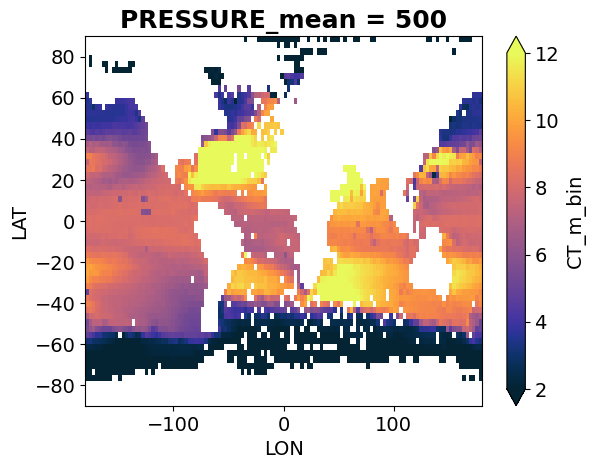

In [73]:
ds_pbar_grid.sel(PRESSURE_mean=500).CT_m_bin.plot(x='LON', y='LAT', cmap=cmo.thermal, vmin=2, vmax=12)

In [72]:
ds_pbar = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grid_flux.nc')

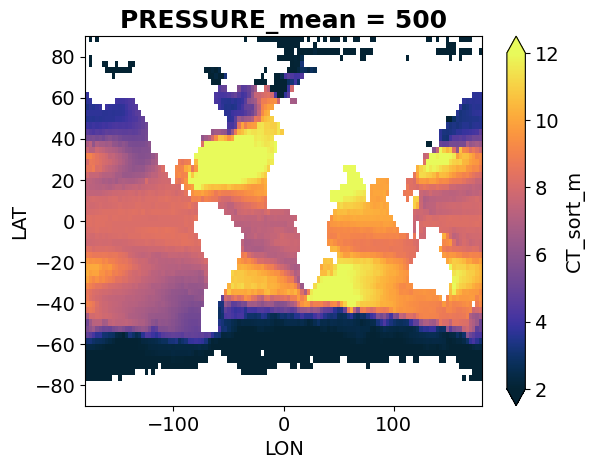

In [75]:
ds_pbar.sel(PRESSURE_mean=500).CT_sort_m.plot(x='LON', y='LAT', cmap=cmo.thermal, vmin=2, vmax=12)

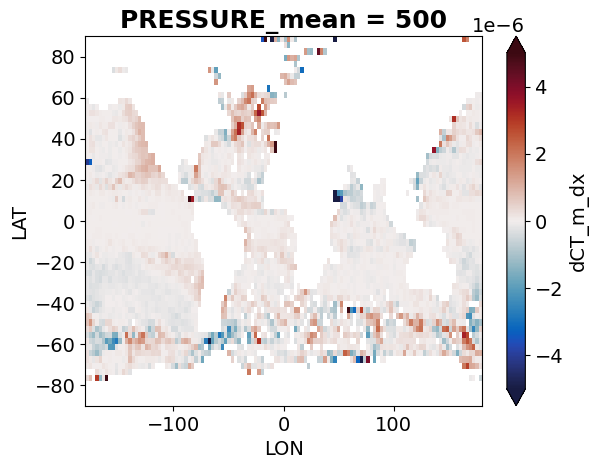

In [83]:
ds_pbar_grid.sel(PRESSURE_mean=500).dCT_m_dx.plot(x='LON',y='LAT', cmap=cmo.balance, vmin=-5e-6, vmax=5e-6)

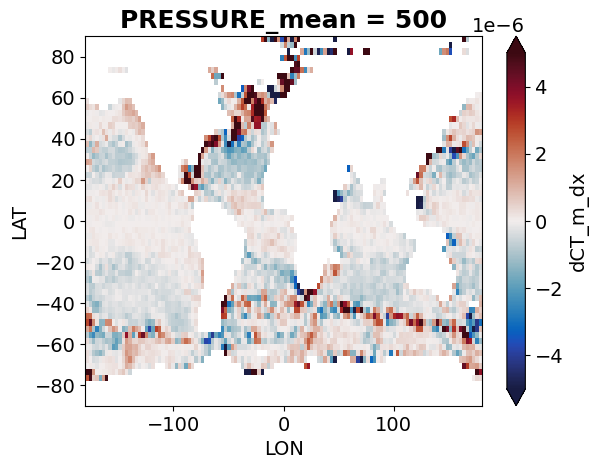

In [84]:
ds_pbar.sel(PRESSURE_mean=500).dCT_m_dx.plot(x='LON',y='LAT', cmap=cmo.balance, vmin=-5e-6, vmax=5e-6)